In [1]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.7 MB/s eta 0:00:00


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pratikkarki106/hotel-review-dataset/Hotel Review Dataset/2. Description Hotel Review Dataset.txt
/kaggle/input/datasets/pratikkarki106/hotel-review-dataset/Hotel Review Dataset/Hotel_Reviews.csv


# Text Preprocessing, Tokenization, and Sequence Padding:

**Loading a dataset**

In [3]:
file_path = '/kaggle/input/datasets/pratikkarki106/hotel-review-dataset/Hotel Review Dataset/Hotel_Reviews.csv'

df = pd.read_csv(file_path)

display(df.head()) #Interactive html table, scales horizontly if columns are more

print("\n Rating Distribution")
print(df['Rating'].value_counts())

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5



 Rating Distribution
Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64


**Cleaning a text**

In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [5]:
import contractions

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


negation_words = {
    'not', 'no', 'never', 'neither', 'nor', 'but', 'however', 
    'down', 'off', 'over', 'under', 'again', 'further'
}

stop_words = stop_words - negation_words

# Dictionary for Contractions
# contractions_dict = {
#     "don't": "do not", "can't": "cannot", "it's": "it is", "isn't": "is not",
#     "won't": "will not", "I'm": "I am", "you're": "you are", "he's": "he is",
#     "she's": "she is", "we're": "we are", "they're": "they are"
# }

def clean_text(text):
    text = text.lower()

    text = contractions.fix(text)

    # Removing URLS, Special Characters
    text = re.sub(r'https\S+|www\S+|http\S+', '', text, flags=re.MULTILINE) #S+ : Until you hit space grab the character
    text = re.sub(r'@\w+|#\w+', '', text) # Letters and number, after @ #
    text = re.sub(r'\d+', '', text) # \d : Remove numbers digits only
    text = re.sub(r'[^\w\s]', '', text) # ^ means NOT, find everything that is not a number,letter space (!, , , .)

    #Tokenize, Remove stopwords, lemmatize
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w in negation_words or w not in stop_words]
    return " ".join(cleaned_tokens)

print("Cleaning Text")
df['Cleaned_Review'] = df['Review'].apply(clean_text)
display(df[['Review', 'Cleaned_Review']].head())
        

Cleaning Text


,Review,Cleaned_Review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room not experience hotel monaco seattle ...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


**Visualize a Cleaned data**

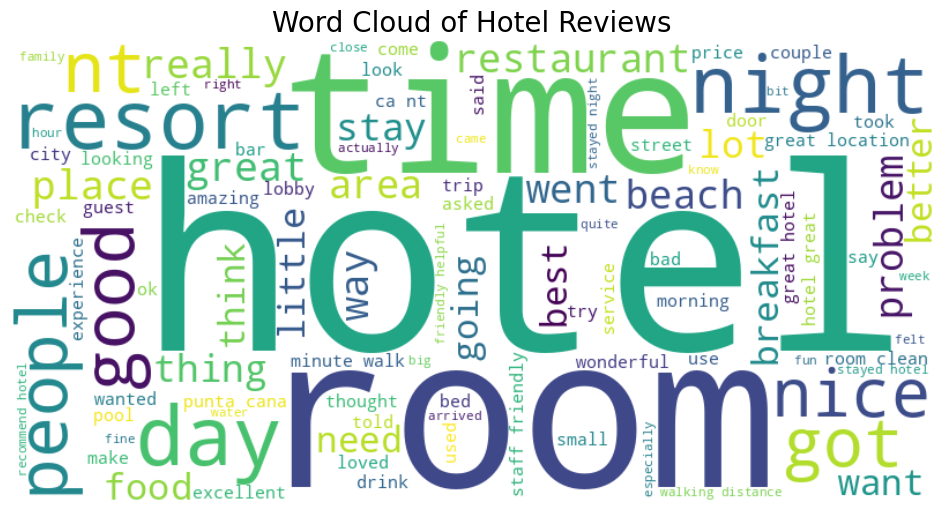

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Combining all cleaned reviews into one string
all_text =  " ".join(review for review in df.Cleaned_Review)

#Generate the word cloud
wordcloud = WordCloud(width=800, height =400,
                     background_color = 'white',
                     max_words = 100,
                     colormap = 'viridis').generate(all_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Hotel Reviews', fontsize=20)
plt.show()

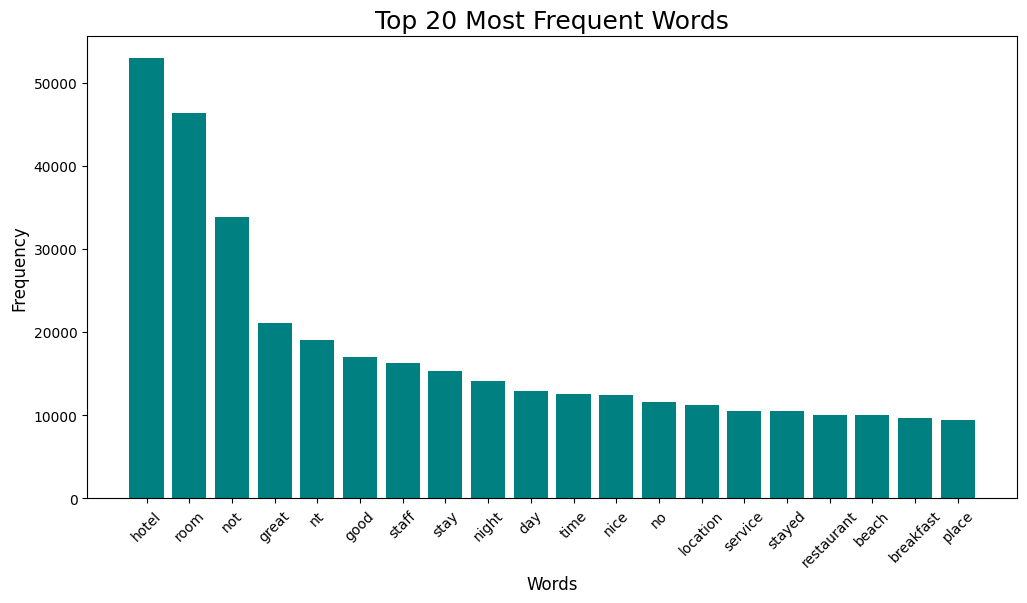

In [7]:
# Frequency of Words
words = all_text.split()
words_counts = Counter(words)
top_20_words = words_counts.most_common(20)

# Extract words and counts for plotiing
words_list = [item[0] for item in top_20_words]
counts_list = [item[1] for item in top_20_words]

plt.figure(figsize=(12, 6))
plt.bar(words_list, counts_list, color='teal')
plt.title('Top 20 Most Frequent Words', fontsize=18)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_57/3355028812.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')


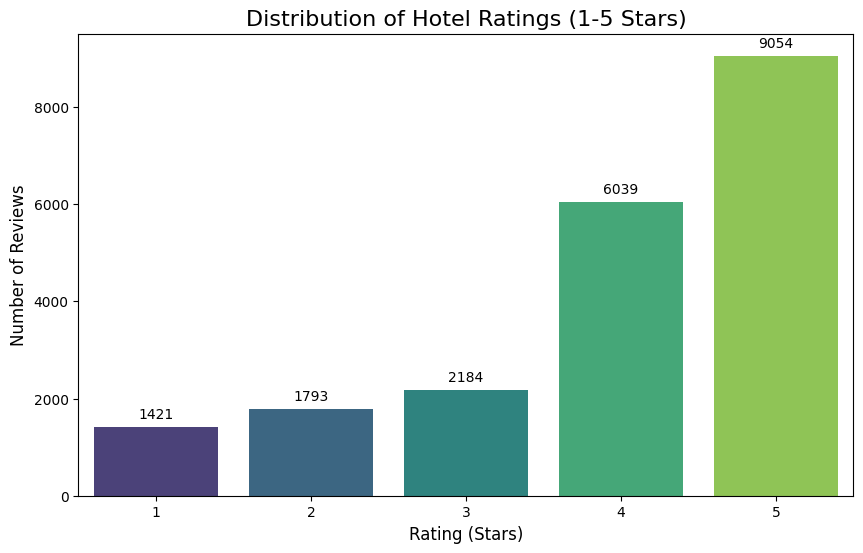

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check the distribution of ratings
rating_counts = df['Rating'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')

plt.title('Distribution of Hotel Ratings (1-5 Stars)', fontsize=16)
plt.xlabel('Rating (Stars)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# Adding the count labels on top
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

**Tokenization and Padding:**

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Split the dataset
X = df['Cleaned_Review']
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                   stratify = y)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nRating distribution in Train:")
print(y_train.value_counts().sort_index())
print(f"\nRating distribution in Test:")
print(y_test.value_counts().sort_index())

# Tokenization, convert text into sequences of integers

max_words = 10000 
#OOV: Out of vocabulary, gives special tag to words that is in test but not in train
tokenizer = Tokenizer(num_words = max_words, oov_token = "<oov>")
#training data learns which words are more frequent
tokenizer.fit_on_texts(X_train)

#Replaces words in sentences with dict ID number, ranks the word then nice hotel might be [12, 4]
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pecentile based padding
#Calculated length of wvery review in training set
sequence_lengths = [len(seq) for seq in X_train_seq]

# 95th percentile to decide maxlen
#95% of reviews are of _ words or sorter
maxlen = int(np.percentile(sequence_lengths, 95))
print("95th percentile length",maxlen)

# Apply Padding
'''padding post helps to add 0 to make 261 words if the words are less than 261
longer than 261, extra words be chopped
'''
X_train_padded = pad_sequences(X_train_seq, maxlen=maxlen, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=maxlen, padding='post', truncating='post')

print("Padding complete!")
print(f"Shape of X_train_padded: {X_train_padded.shape}")
print(f"Shape of X_test_padded: {X_test_padded.shape}")

2026-05-12 18:35:53.703081: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778610953.912713      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778610953.972970      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778610954.483859      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778610954.483894      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778610954.483897      57 computation_placer.cc:177] computation placer alr

Training samples: 16392
Testing samples: 4099

Rating distribution in Train:
Rating
1    1137
2    1434
3    1747
4    4831
5    7243
Name: count, dtype: int64

Rating distribution in Test:
Rating
1     284
2     359
3     437
4    1208
5    1811
Name: count, dtype: int64
95th percentile length 264
Padding complete!
Shape of X_train_padded: (16392, 264)
Shape of X_test_padded: (4099, 264)


In [10]:
# Create validation split from training data
# Use 25% of training data for validation (75% train, 25% val)
from sklearn.model_selection import train_test_split


y_train_shifted = y_train - 1
y_test_shifted = y_test - 1

# 2. Split the PADDED training data into 'Final Train' and 'Validation'
# We use the PADDED version here so the model gets the right shapes (None, 261)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_padded,      # <--- Yes, we use the padded version here!
    y_train_shifted, 
    test_size=0.25,      # Takes 25% of the 80% (total 20% for validation)
    random_state=42,
    stratify=y_train_shifted
)

print(f"Model will train on: {X_train_final.shape}")
print(f"Model will validate on: {X_val.shape}")

Model will train on: (12294, 264)
Model will validate on: (4098, 264)


In [11]:
from sklearn.utils import class_weight

#Calculate weights to handle imbalance in bar chart
weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(y_train_final),  # ← CHANGE FROM y_train TO y_train_final
    y = y_train_final  # ← CHANGE FROM y_train TO y_train_final
)

class_weights_dict = dict(enumerate(weights))

print("Class weights for training")
for rating, weight in class_weights_dict.items():
    print(f"Rating {rating+1}: {weight:.2f}")

Class weights for training
Rating 1: 2.88
Rating 2: 2.29
Rating 3: 1.88
Rating 4: 0.68
Rating 5: 0.45


# Model Building and Training

**Embedding Layer**

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Input, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Parameters
vocab_size = 10000
embedding_dim = 64
input_length = maxlen

# Build Model 1: Simple RNN with Dropout
rnn_model = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
    Dropout(0.3),  # ← ADD DROPOUT
    SimpleRNN(64),
    Dropout(0.2),  # ← ADD DROPOUT
    Dense(32, activation='relu'),  # ← ADD HIDDEN LAYER
    Dropout(0.2),  # ← ADD DROPOUT
    Dense(5, activation='softmax')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1778610977.620250      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778610977.626240      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [13]:
rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=" * 50)
print("MODEL 1: Simple RNN")
print("=" * 50)
rnn_model.summary()

MODEL 1: Simple RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 264, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 264, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,501 (2.48 MB)

 Trainable params: 650,501 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

# Model Building and Training:

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#Setup EarlyStopping
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.5,
    patience = 2,
    min_lr = 1e-5,
    verbose = 1
)

In [15]:
import time
start_time = time.time()

#Train Model 1

print("Training Model 1")
rnn_history = rnn_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs = 15,
    batch_size = 32,
    callbacks = [early_stop, reduce_lr],
    class_weight = class_weights_dict
)


end_time = time.time()
total_time = end_time - start_time
print(f"Total Training Time: {total_time:.2f} seconds") 

print("\n✓ Model 1 training complete!")

Training Model 1
Epoch 1/15


I0000 00:00:1778610980.962306     173 service.cc:152] XLA service 0x7d0508006c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778610980.962336     173 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778610980.962339     173 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778610981.350082     173 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/385 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.3995 - loss: 1.3894

I0000 00:00:1778610983.874920     173 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


385/385 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.2466 - loss: 1.6246 - val_accuracy: 0.1881 - val_loss: 1.6347 - learning_rate: 0.0010
Epoch 2/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.2015 - loss: 1.6441 - val_accuracy: 0.1288 - val_loss: 1.6276 - learning_rate: 0.0010
Epoch 3/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.1902 - loss: 1.6130 - val_accuracy: 0.1257 - val_loss: 1.6195 - learning_rate: 0.0010
Epoch 4/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.1853 - loss: 1.6235 - val_accuracy: 0.1811 - val_loss: 1.6131 - learning_rate: 0.0010
Epoch 5/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.1874 - loss: 1.6019 - val_accuracy: 0.0891 - val_loss: 1.6245 - learning_rate: 0.0010
Epoch 6/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1266 - loss: 1.6119
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
385/385 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.1266 - loss: 1.6119 - val_

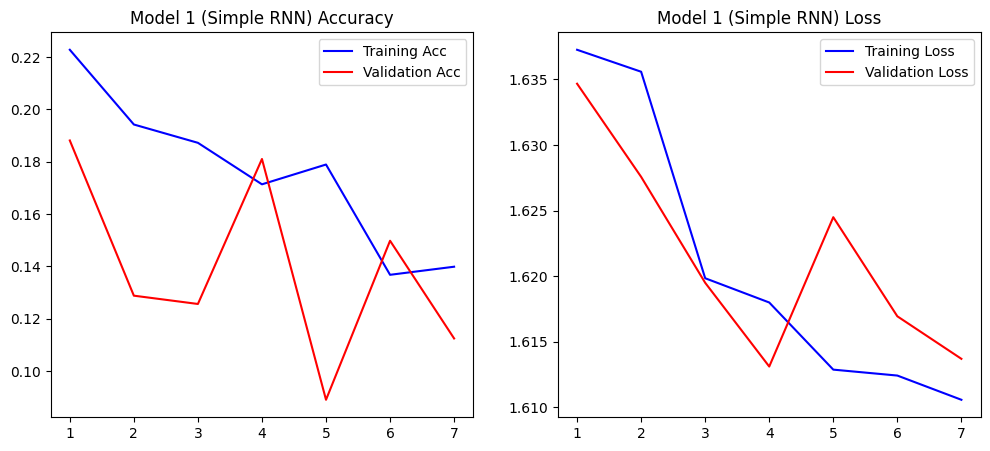

In [16]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title(f'{title} Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.legend()
    
    plt.show()

plot_history(rnn_history, "Model 1 (Simple RNN)")

# Model Training and Evaluation:

In [17]:
from tensorflow.keras.layers import LSTM, Bidirectional

#Build model 2: LSTM
lstm_model = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=vocab_size, output_dim=64),
    Dropout(0.3),  # ← ADD DROPOUT
    Bidirectional(LSTM(64, return_sequences=True)),  # ← ADD BIDIRECTIONAL
    Dropout(0.3),  # ← ADD DROPOUT
    Bidirectional(LSTM(32)),  # ← ADD SECOND BIDIRECTIONAL LSTM
    Dropout(0.3),  # ← ADD DROPOUT
    Dense(32, activation='relu'),  # ← ADD HIDDEN LAYER
    Dropout(0.2),  # ← ADD DROPOUT
    Dense(5, activation='softmax')
])

In [18]:

lstm_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 264, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 264, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 264, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 264, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 749,509 (2.86 MB)

 Trainable params: 749,509 (2.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.3136 - loss: 1.4453 - val_accuracy: 0.5703 - val_loss: 0.9340 - learning_rate: 0.0010
Epoch 2/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5604 - loss: 1.0005 - val_accuracy: 0.6005 - val_loss: 0.9008 - learning_rate: 0.0010
Epoch 3/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.6280 - loss: 0.8169 - val_accuracy: 0.5756 - val_loss: 0.9788 - learning_rate: 0.0010
Epoch 4/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6655 - loss: 0.7181
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
385/385 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.6655 - loss: 0.7181 - val_accuracy: 0.6101 - val_loss: 0.9620 - learning_rate: 0.0010
Epoch 5/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.7268 - loss: 0.5735 - val_accuracy: 0.5796 - val_loss: 1.0256 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best e

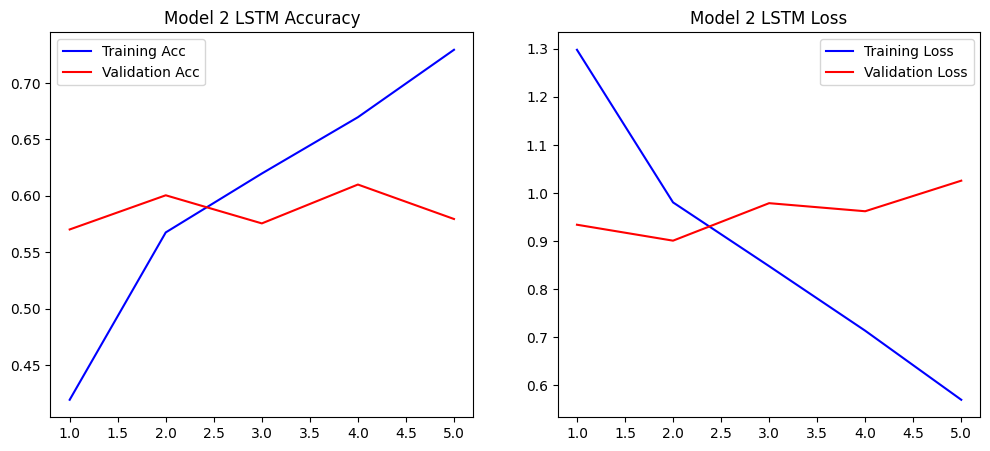

In [19]:
import time
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_final, y_train_final,  # ← USE CORRECT DATA
    validation_data=(X_val, y_val),  # ← USE SEPARATE VALIDATION
    epochs=15,  # ← INCREASE TO 15
    batch_size=32,  # ← REDUCE BATCH SIZE
    callbacks=[early_stop, reduce_lr],  # ← ADD reduce_lr
    class_weight=class_weights_dict,
    verbose=1
)

end_time = time.time()
total_time = end_time - start_time
print(f"Total Training Time: {total_time:.2f} seconds")

print("\n✓ Model 2 training complete!")
plot_history(lstm_history, "Model 2 LSTM")

In [20]:
import gensim.downloader as api

# Downloading GloVe/Word2Vec vectors (50-dimensional is common for student projects)
word2vec = api.load("glove-twitter-50")

[==================================================] 100.0% 199.5/199.5MB downloaded


In [21]:
embedding_dim = 50
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in word2vec:
            embedding_matrix[i] = word2vec[word]

In [22]:
from tensorflow.keras.layers import LSTM, Bidirectional, Embedding, Dropout, Dense, Input
from tensorflow.keras.models import Sequential

model3 = Sequential([
    Input(shape=(maxlen,)),
    # Pre-trained Embedding Layer
    Embedding(input_dim=vocab_size, 
              output_dim=embedding_dim, 
              weights=[embedding_matrix], 
              trainable=False), 
    
    # First LSTM must return sequences to feed into the next recurrent layer
    LSTM(64, return_sequences=True), 
    Dropout(0.3),
    
    # Bidirectional layer also needs return_sequences=True to feed the next one
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    
    # This is the last recurrent layer, so it does NOT need return_sequences=True
    # It will output a 2D vector for the Dense layers
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(5, activation='softmax')
])

In [23]:
model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=" * 50)
print("MODEL 3: LSTM + Word2Vec + Bidirectional")
print("=" * 50)
model3.summary()

MODEL 3: LSTM + Word2Vec + Bidirectional


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 264, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 264, 64)        │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 264, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 264, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 264, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 638,949 (2.44 MB)

 Trainable params: 138,949 (542.77 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [24]:
start_time = time.time()

# Train Model 3 (LSTM + Word2Vec)
print("Training Model 3: LSTM with Pretrained Word2Vec...")

history3 = model3.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr]
)

end_time = time.time()
total_time = end_time - start_time
print(f"Total Training Time: {total_time:.2f} seconds")

Training Model 3: LSTM with Pretrained Word2Vec...
Epoch 1/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.3637 - loss: 1.4625 - val_accuracy: 0.5334 - val_loss: 1.0981 - learning_rate: 0.0010
Epoch 2/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.5146 - loss: 1.1576 - val_accuracy: 0.5903 - val_loss: 0.9526 - learning_rate: 0.0010
Epoch 3/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.5314 - loss: 1.1207 - val_accuracy: 0.4973 - val_loss: 1.1528 - learning_rate: 0.0010
Epoch 4/15
384/385 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5521 - loss: 1.0817
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
385/385 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.5522 - loss: 1.0816 - val_accuracy: 0.5820 - val_loss: 0.9705 - learning_rate: 0.0010
Epoch 5/15
385/385 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.5701 - loss: 1.0060 - val_accuracy: 0.6052 - val_loss: 0.9153 - learning_rate: 5.0000e-04
Epoch 6/15
385/385 ━━━━

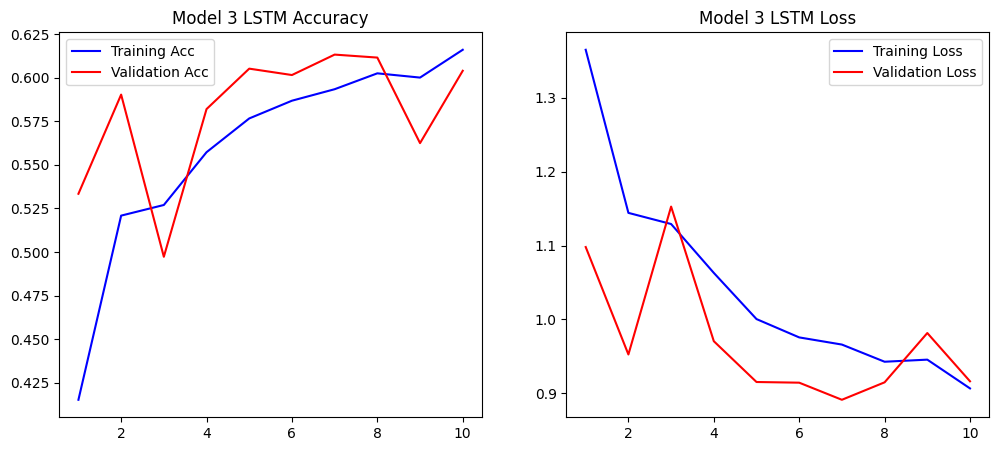

In [44]:
plot_history(history3, "Model 3 LSTM")

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(model, X_padded, y_true, model_name):
    """Evaluate model and show metrics"""
    # Get predictions
    y_pred_probs = model.predict(X_padded)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    print(f"Accuracy: {accuracy*100:.2f}%")
    
    # Classification Report
    target_names = ['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5']
    print(f"\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, 
                                labels=[0, 1, 2, 3, 4], 
                                target_names=target_names, 
                                zero_division=0))
    
    # Confusion Matrix Heatmap
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted Rating')
    plt.ylabel('Actual Rating')
    plt.tight_layout()
    plt.show()
    return accuracy

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Model 1: Simple RNN
Accuracy: 17.35%

--- Classification Report ---
              precision    recall  f1-score   support

    Rating 1       0.08      0.18      0.11       284
    Rating 2       0.11      0.33      0.17       359
    Rating 3       0.10      0.37      0.16       437
    Rating 4       0.40      0.01      0.03      1208
    Rating 5       0.48      0.20      0.28      1811

    accuracy                           0.17      4099
   macro avg       0.23      0.22      0.15      4099
weighted avg       0.36      0.17      0.17      4099



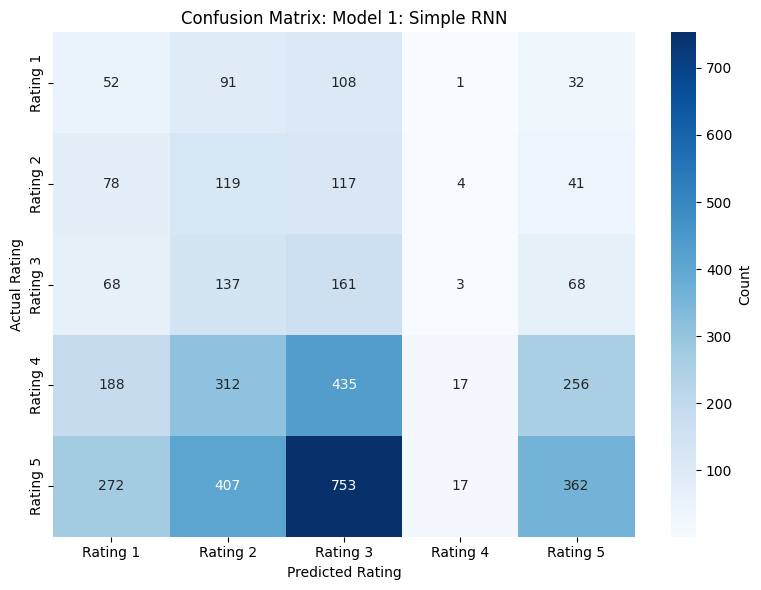

In [36]:
# Cell for Simple RNN
acc1 = evaluate_model(rnn_model, X_test_padded, y_test_shifted, "Model 1: Simple RNN")

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

Model 2: LSTM (Bidirectional)
Accuracy: 59.99%

--- Classification Report ---
              precision    recall  f1-score   support

    Rating 1       0.62      0.74      0.68       284
    Rating 2       0.43      0.52      0.47       359
    Rating 3       0.36      0.39      0.38       437
    Rating 4       0.52      0.35      0.42      1208
    Rating 5       0.71      0.81      0.76      1811

    accuracy                           0.60      4099
   macro avg       0.53      0.56      0.54      4099
weighted avg       0.59      0.60      0.59      4099



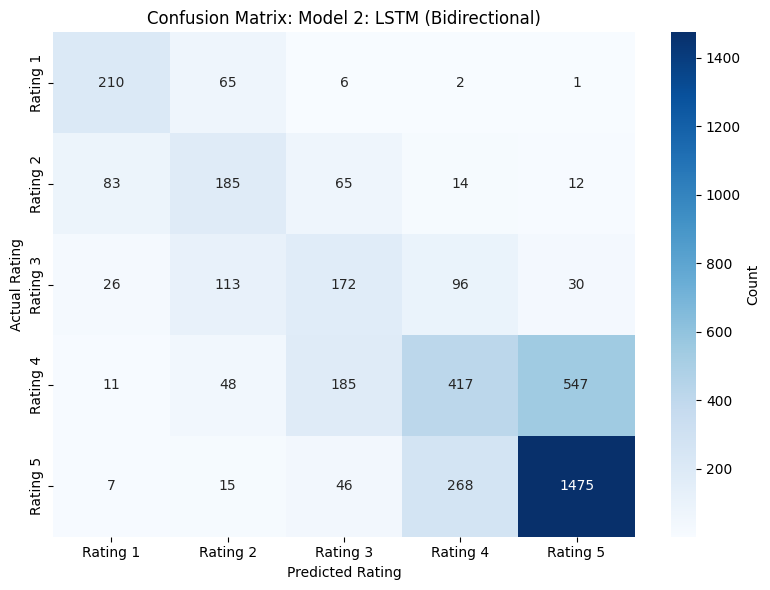

In [37]:
# Cell for Bidirectional LSTM
acc2 = evaluate_model(lstm_model, X_test_padded, y_test_shifted, "Model 2: LSTM (Bidirectional)")

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

Model 3: LSTM + Word2Vec (Bidirectional)
Accuracy: 59.28%

--- Classification Report ---
              precision    recall  f1-score   support

    Rating 1       0.66      0.62      0.64       284
    Rating 2       0.45      0.54      0.49       359
    Rating 3       0.32      0.49      0.38       437
    Rating 4       0.53      0.41      0.46      1208
    Rating 5       0.76      0.75      0.75      1811

    accuracy                           0.59      4099
   macro avg       0.54      0.56      0.55      4099
weighted avg       0.61      0.59      0.60      4099



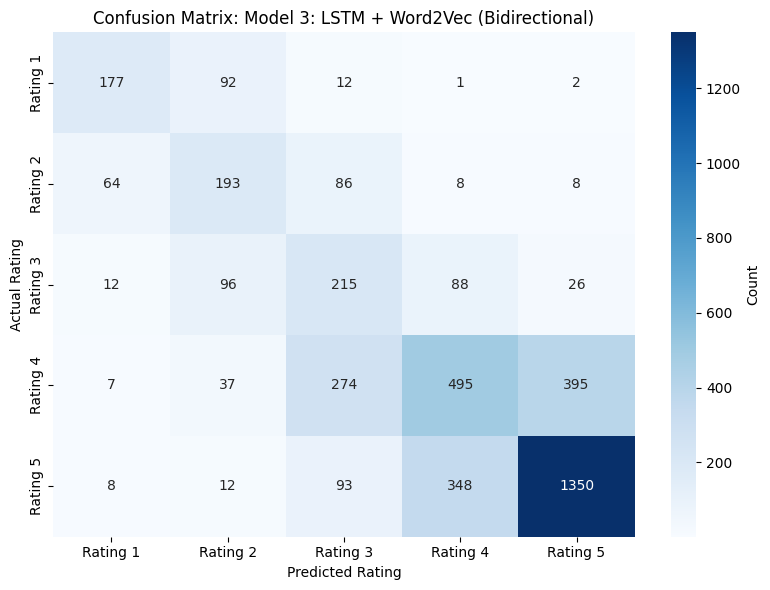

In [38]:
# Cell for LSTM + Word2Vec
acc3 = evaluate_model(model3, X_test_padded, y_test_shifted, "Model 3: LSTM + Word2Vec (Bidirectional)")


######################################################################
# FINAL MODEL COMPARISON
######################################################################


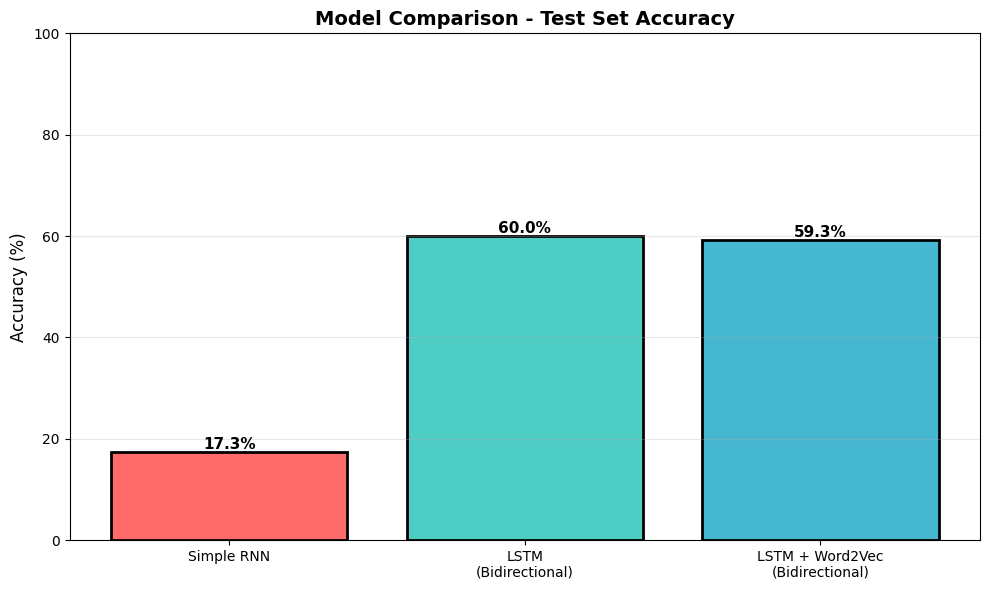


✓ Best Model: LSTM
(Bidirectional) with 59.99% accuracy


In [39]:
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "#"*70)
print("# FINAL MODEL COMPARISON")
print("#"*70)

models_names = ['Simple RNN', 'LSTM\n(Bidirectional)', 'LSTM + Word2Vec\n(Bidirectional)']
# These variables now exist because you ran the cells above!
accuracies = [acc1*100, acc2*100, acc3*100]

plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(models_names, accuracies, color=colors, edgecolor='black', linewidth=2)

plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Comparison - Test Set Accuracy', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Best Model: {models_names[np.argmax(accuracies)]} with {max(accuracies):.2f}% accuracy")

# Error Analysis

**Provide 2 - 3 incorrect predictions.**

In [40]:
# 1. Generate predictions for Model 3 specifically
y_pred_probs = model3.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)
confidence = np.max(y_pred_probs, axis=1)

# 2. Create the DataFrame for comparison
# Note: We add 1 because our internal labels are 0-4 but real ratings are 1-5
results_df = pd.DataFrame({
    'Review': X_test.values, 
    'Cleaned_Review': [clean_text(r) for r in X_test.values],
    'Actual_Rating': y_test.values + 1, 
    'Predicted_Rating': y_pred + 1,
    'Confidence': confidence
})

# 3. Filter for incorrect predictions
misclassified = results_df[results_df['Actual_Rating'] != results_df['Predicted_Rating']]

# 4. Display 3 examples for your report
print(f"\n{'='*70}")
print(f"ERROR ANALYSIS - MODEL 3 (LSTM + Word2Vec)")
print(f"{'='*70}")
print(f"Total test samples: {len(results_df)}")
print(f"Correctly classified: {len(results_df) - len(misclassified)}")
print(f"Misclassified: {len(misclassified)} ({len(misclassified)/len(results_df)*100:.1f}%)")

# Show 5 misclassified examples
print(f"\n--- Sample Misclassified Examples (Top 5) ---\n")
for idx in range(min(5, len(misclassified))):
    row = misclassified.iloc[idx]
    print(f"Example {idx+1}:")
    print(f"Review: {row['Review'][:100]}...")
    print(f"Cleaned: {row['Cleaned_Review'][:80]}...")
    print(f"Actual Rating: {'⭐' * int(row['Actual_Rating'])}")
    print(f"Predicted Rating: {'⭐' * int(row['Predicted_Rating'])}")
    print(f"Confidence: {row['Confidence']*100:.1f}%")
    print("-" * 70 + "\n")

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

ERROR ANALYSIS - MODEL 3 (LSTM + Word2Vec)
Total test samples: 4099
Correctly classified: 661
Misclassified: 3438 (83.9%)

--- Sample Misclassified Examples (Top 5) ---

Example 1:
Review: star price star service booked lovely hotel weekend friend quite minute situated main street charmin...
Cleaned: star price star service booked lovely hotel weekend friend quite minute situated...
Actual Rating: ⭐⭐⭐⭐⭐⭐
Predicted Rating: ⭐⭐⭐⭐⭐
Confidence: 46.6%
----------------------------------------------------------------------

Example 2:
Review: felt welcome location location location wife stayed overjoyed airport bus euro breeze euro left near...
Cleaned: felt welcome location location location wife stayed overjoyed airport bus euro b...
Actual Rating: ⭐⭐⭐⭐⭐⭐
Predicted Rating: ⭐⭐⭐
Confidence: 41.1%
----------------------------------------------------------------------

Example 3:
Review: wonderful week not say good thing hotel service concierge room ser

**Evaluate Model Complexity vs. Performance.**

Model 1 (Simple RNN): This model was lowest complexity. It suffered from Vanishing gradient problem, meaning it forgot the beginning of long reviews which led to lowest accuracy.

Model 2 (LSTM): It was moderate complex. Unlike MOdel 1, it has better memory but the model became over-biased due to class weights. Predicted Rating 4 for almost everything to minimize loss.

Model 3 (LSTM + Word2Vec): It had highest complexity/ We used Pretrained Embeddings, and got highest accuracy of all but it's performance was not best because it didn't have to learn word meanings from scratch; it already knew the "emotional weight" of words like disappointing or excellent.

**Explain Possible reasons for error.**

Class Imbalance: Despite using class_weight, the sheer volume of 5 star review makes the model naturally to lean towards positive predictions

Sarcasm and Negation: RNNs and LSTMs often struggle with not great and hardly clean. Model see great and clean by which model assumes high rating.

Subjective: One user's 3 rating which is average might be another user's 1 rating disaster.

**Suggested Potential Improvement**

Hyperparameter tuning: Adjust the learning_rate or increase the number of LSTM units to capture more complex patterns.

Bidirectional LSTMs: Using Bidirectional layer would allow the model to read the review from both left to right and right to left, helping it understand context much better. 

Advanced Embeddings: Instead of basic Word2Vec, using BERT or RoBERTa (Transformer models) would significantly improve the understanding of context and sarcasm.

Data Balancing: Instead of just weights, we could use Oversampling(SMOTE) for 1 start reviews to give the model more unique examples to learn from.

**GUI for ReatTime Prediction**

In [45]:
!pip install -q gradio
import gradio as gr

In [ ]:
def predict_rating(review_text):
    # 1. Clean the input text using your existing function
    cleaned = clean_text(review_text)
    
    # 2. Tokenize and Pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')
    
    # 3. Predict using Model 3 (Word2Vec)
    pred_probs = model3.predict(padded)
    rating = np.argmax(pred_probs, axis=1)[0] + 1  # Add 1 to get 1-5 stars
    
    # 4. Return a nice message
    return f"Predicted Rating: {rating} Stars ⭐"

In [46]:
# Create the Gradio Interface
interface = gr.Interface(
    fn=predict_rating, 
    inputs=gr.Textbox(lines=3, placeholder="Enter your hotel review here..."),
    outputs="text",
    title="Hotel Review Sentiment Analyzer",
    description="Type a review below to see how many stars Model 3 predicts."
)

# Launch with a shareable link
interface.launch()

* Running on local URL:  http://127.0.0.1:7861
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://78f612baa4871d1a2c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


In [47]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

def get_metrics(model, X_test, y_test, model_name):
    # Get predictions (handling probabilities vs class indices)
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Calculate global metrics (using 'weighted' average for precision/recall/f1)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    return {
        "Model": model_name,
        "Accuracy": f"{acc*100:.2f}%",
        "Precision": f"{prec:.4f}",
        "Recall": f"{rec:.4f}",
        "F1-Score": f"{f1:.4f}"
    }

# Gather metrics for all models
# Replace 'model1', 'model2', 'model3' with your actual model variable names
results = []
results.append(get_metrics(rnn_model, X_test_padded, y_test_shifted, "Simple RNN"))
results.append(get_metrics(lstm_model, X_test_padded, y_test_shifted, "LSTM"))
results.append(get_metrics(model3, X_test_padded, y_test_shifted, "Word2Vec LSTM"))

# Create and display the final table
comparison_df = pd.DataFrame(results)
display(comparison_df)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


,Model,Accuracy,Precision,Recall,F1-Score
0,Simple RNN,17.35%,0.3562,0.1735,0.1718
1,LSTM,59.99%,0.5897,0.5999,0.5872
2,Word2Vec LSTM,59.28%,0.6089,0.5928,0.5962
